# 03 — From probabilities to cells

The network gives, for every pixel, the probability of being part of a cell. This notebook turns these probability maps into
individual cells, step by step, and explains each choice on the **validation images** (43 images the network was not
trained on; the test images are used only in notebook 04).

The adopted pipeline:

```
probability map → threshold 0.5 → fill holes → remove objects < 120 px
                → watershed (seeds at least 20 px apart): split touching cells
                → object classifier: drop objects that are probably not annotated cells
                → cells and their count
```


In [2]:
import json
import os
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import ndimage
from skimage import measure
from skimage.feature import peak_local_max

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from evaluation.metrics import overlap_tables
from evaluation.object_features import FEATURES
from evaluation.postprocess import label_instances, postprocess, predict_labels
from evaluation.predict import load_model, predict_probs
from evaluation.select_object_classifier import CANDIDATES, THRESHOLDS, object_prf, oof_scores
from evaluation.tune import bootstrap_diff, counts_row, metrics_from_counts
from evaluation.watershed_classifier import MIN_DISTANCE, THRESHOLD, delivered_labels
from train.dataset import GreenEvalDataset, load_img_and_masks, load_split
from train.split import count_from_coco

IMG_DIR = Path("data/green/trainval/images")
MASK_DIR = Path("data/cleaned_masks/trainval/Green/masks")
COCO = Path("data/green/trainval/ground_truths/COCO/annotations_green_trainval.json")
RUN = Path("runs/green_v2")

## 1. From the checkpoint to probability maps

The adopted network (`runs/green_v2/best.pt`) predicts the 43 validation images, one full image at a time.

In [3]:
train_names, val_names = load_split(Path("splits/green_split.json"))
images, masks = load_img_and_masks(IMG_DIR, MASK_DIR, val_names)
true_masks = masks > 0

model, mean, std, epoch, norm = load_model(RUN / "best.pt", torch.device("cpu"))
dataset = GreenEvalDataset(images, masks, val_names, mean, std, norm=norm)
start = time.time()
probs, names = predict_probs(model, dataset, torch.device("cpu"))
probs = probs.astype(np.float32)
print(f"{len(probs)} probability maps in {time.time() - start:.0f} s (checkpoint of epoch {epoch})")

# check: the pixel Dice at threshold 0.5 is the validation Dice of the training log
predicted = probs > 0.5
dice = 2 * (predicted & true_masks).sum() / (predicted.sum() + true_masks.sum())
print(f"validation Dice at 0.5: {dice:.4f}")

43 probability maps in 165 s (checkpoint of epoch 79)
validation Dice at 0.5: 0.7618


## 2. Threshold: 0.5

A pixel is "cell" if its probability is above the threshold. The network is very confident: almost all probabilities are
close to 0 or to 1.

pixels with a probability between 0.1 and 0.9: 0.14%


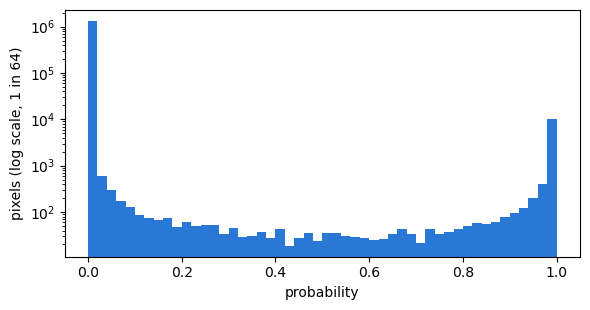

In [4]:
uncertain = (probs > 0.1) & (probs < 0.9)
print(f"pixels with a probability between 0.1 and 0.9: {100 * uncertain.mean():.2f}%")

plt.figure(figsize=(6, 3.2))
plt.hist(probs[::4, ::4, ::4].ravel(), bins=50, color="#2a78d6")
plt.yscale("log")
plt.xlabel("probability")
plt.ylabel("pixels (log scale, 1 in 64)")
plt.tight_layout()
plt.show()

So the exact threshold matters little. Object metrics for five thresholds (with the post-processing of section 3), and the
difference of the F1 from the threshold 0.5 with its 95% bootstrap interval over the images:

In [5]:
def network_counts(threshold):
    '''Per-image counts of the network + basic post-processing (no watershed, no classifier).'''
    rows = []
    for prob, true_mask in zip(probs, true_masks):
        labels = label_instances(postprocess(prob, threshold))
        rows.append(counts_row(labels, true_mask))
    return np.array(rows)

counts_by_threshold = {}
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    counts_by_threshold[threshold] = network_counts(threshold)

table = []
for threshold, counts in counts_by_threshold.items():
    metrics = metrics_from_counts(counts)
    low, high = bootstrap_diff(counts, counts_by_threshold[0.5], "obj_f1")
    table.append({"threshold": threshold, "Dice": metrics["dice"], "F1": metrics["obj_f1"],
                  "precision": metrics["obj_precision"], "recall": metrics["obj_recall"],
                  "F1 - F1(0.5), 95% CI": f"[{low:+.3f}, {high:+.3f}]"})
print(pd.DataFrame(table).round(3).to_string(index=False))

 threshold  Dice    F1  precision  recall F1 - F1(0.5), 95% CI
       0.3 0.762 0.782      0.731   0.840     [-0.009, +0.010]
       0.4 0.762 0.781      0.732   0.837     [-0.005, +0.004]
       0.5 0.763 0.782      0.734   0.837     [+0.000, +0.000]
       0.6 0.762 0.783      0.735   0.837     [-0.006, +0.007]
       0.7 0.761 0.786      0.741   0.837     [-0.002, +0.011]


No threshold is demonstrably better than 0.5 (every interval contains 0), so the natural value 0.5 is kept.

**How the object metrics work** (used in the whole notebook): the predicted mask is split into objects (connected
components); a predicted object and an annotated cell are a match if they overlap with IoU > 0.5. Matches are true
positives (TP); unmatched predicted objects are false positives (FP); unmatched annotated cells are false negatives (FN).
Precision = TP / predicted objects, recall = TP / annotated cells, F1 = their harmonic mean.

## 3. Filling holes and removing small objects

- **Fill holes:** c-FOS stains the nucleus, but the nucleolus inside often stays dark; a cell can become a ring. Holes are
  filled before anything else, so a ring counts as one full cell.
- **Remove objects smaller than 120 px**, the same rule used to clean the annotations (notebook 01): the smallest annotated
  cell has 126 px.

The training images show that small predicted objects are almost never cells (objects of the network on the 169 training
images, after these two steps; "true" = matches an annotated cell):

In [6]:
objects_train = pd.read_csv(RUN / "object_classifier" / "objects_train.csv")   # one row per predicted object
bands = [120, 250, 400, 600, 10_000]
for low, high in zip(bands[:-1], bands[1:]):
    in_band = objects_train[(objects_train.area >= low) & (objects_train.area < high)]
    print(f"area {low:5d}-{high:5d} px: {len(in_band):5d} objects, {100 * in_band.label.mean():5.1f}% true")

area   120-  250 px:    73 objects,   0.0% true
area   250-  400 px:   123 objects,  26.0% true
area   400-  600 px:   516 objects,  70.2% true
area   600-10000 px:  2192 objects,  86.4% true


Below 250 px no predicted object is a cell, and below 400 px only a minority is. A larger minimum area (up to 400 px) was
tried: it trades recall for precision without improving the F1 (section 9); the object classifier (section 6), which also
uses the area, handles these small objects better.

## 4. The errors of the network alone

Before adding more steps, what kind of errors does the network (+ the steps above) make on the validation images?

In [7]:
def object_errors(predicted_labels, true_labels):
    '''Error types of one image: predicted objects (TP / FP), annotated cells (FN) and merges.'''
    inter, iou = overlap_tables(predicted_labels, true_labels)       # rows: predicted objects, columns: true cells
    errors = {"TP": 0, "FP isolated": 0, "FP partial": 0, "FN missed": 0, "FN partial": 0, "merged objects": 0}
    for i in range(inter.shape[0]):
        if (iou[i] > 0.5).any():
            errors["TP"] += 1
        elif inter[i].sum() == 0:
            errors["FP isolated"] += 1           # no annotated pixel under it
        else:
            errors["FP partial"] += 1            # touches a cell, but IoU <= 0.5
    for j in range(inter.shape[1]):
        if (iou[:, j] > 0.5).any():
            continue
        if inter[:, j].sum() == 0:
            errors["FN missed"] += 1             # no predicted pixel on it
        else:
            errors["FN partial"] += 1
    cell_area = np.bincount(true_labels.ravel(), minlength=inter.shape[1] + 1)[1:]
    for i in range(inter.shape[0]):
        if ((inter[i] / np.maximum(cell_area, 1)) > 0.5).sum() >= 2:
            errors["merged objects"] += 1        # covers more than half of two or more cells
    return errors

total = {}
for prob, true_mask in zip(probs, true_masks):
    errors = object_errors(label_instances(postprocess(prob, 0.5)), label_instances(true_mask))
    for key, value in errors.items():
        total[key] = total.get(key, 0) + value
print(total)

{'TP': 612, 'FP isolated': 190, 'FP partial': 32, 'FN missed': 74, 'FN partial': 45, 'merged objects': 12}


- **False positives:** most are *isolated* objects, with no annotated pixel under them, not pieces of real cells.
- **False negatives:** most annotated cells that are not found are *missed* completely, not segmented badly.
- **Merged objects:** a few predicted objects cover two touching cells (both cells are then lost).

Are the isolated false positives and the missed cells just noise? Their contrast (mean brightness of the object divided by
the median of its image) compared with the cells found correctly:

cells found (TP)          :  612 objects, median contrast 2.35
isolated false positives  :  190 objects, median contrast 1.95
missed cells              :   74 objects, median contrast 1.75


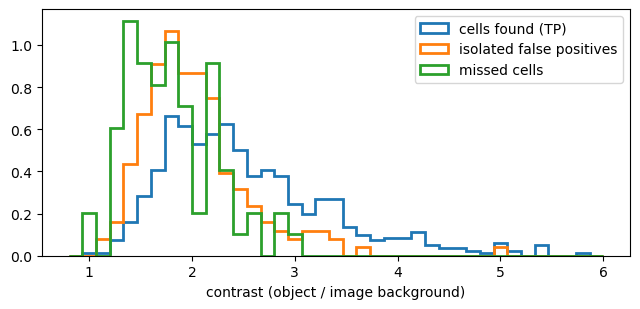

In [8]:
contrast = {"cells found (TP)": [], "isolated false positives": [], "missed cells": []}
for image, prob, true_mask in zip(images, probs, true_masks):
    green = image[..., 1].astype(np.float32)
    background = np.median(green)
    predicted_labels = label_instances(postprocess(prob, 0.5))
    true_labels = label_instances(true_mask)
    inter, iou = overlap_tables(predicted_labels, true_labels)
    for region in measure.regionprops(predicted_labels, intensity_image=green):
        i = region.label - 1
        if (iou[i] > 0.5).any():
            contrast["cells found (TP)"].append(region.intensity_mean / background)
        elif inter[i].sum() == 0:
            contrast["isolated false positives"].append(region.intensity_mean / background)
    for region in measure.regionprops(true_labels, intensity_image=green):
        if inter[:, region.label - 1].sum() == 0:
            contrast["missed cells"].append(region.intensity_mean / background)

for group, values in contrast.items():
    print(f"{group:26s}: {len(values):4d} objects, median contrast {np.median(values):.2f}")

plt.figure(figsize=(6.5, 3.2))
for group, values in contrast.items():
    plt.hist(values, bins=np.linspace(0.8, 6, 40), histtype="step", linewidth=2, density=True, label=group)
plt.xlabel("contrast (object / image background)")
plt.legend()
plt.tight_layout()
plt.show()

The three groups overlap a lot. The isolated false positives look like real cells, only somewhat fainter; the missed cells
are the faintest annotated ones. The annotation protocol of the dataset asks annotators to be conservative with doubtful,
faint cells, and the decision is subjective. So many "errors" are faint cells where the labels themselves are ambiguous:
a limit that no post-processing can fully remove. The two next steps attack what *can* be fixed: merged cells (section 5)
and objects that do not look like annotated cells (section 6).

## 5. Watershed: splitting touching cells

When two cells touch, the predicted mask joins them into one object. The watershed splits such objects using their shape:

1. **distance transform:** every pixel of an object gets its distance from the background; the centre of each cell is a peak;
2. **seeds:** the peaks that are at least **20 px** apart;
3. **watershed:** each pixel of the object is assigned to the closest seed, following the "valleys" of the distance map.

An example from the validation images:

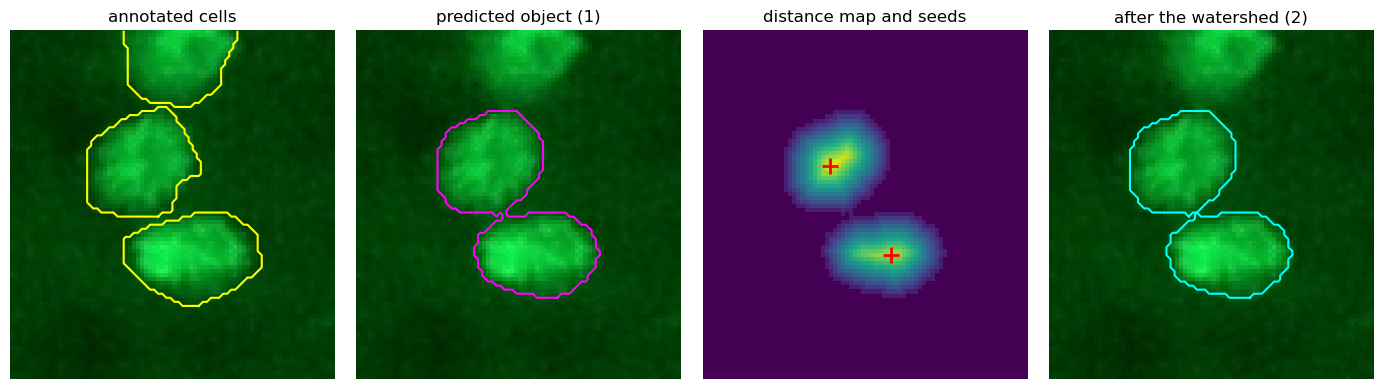

In [9]:
def outline(ax, mask, color):
    for contour in measure.find_contours(np.asarray(mask) > 0, 0.5):
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=1.5)

# find a predicted object that covers two cells and is split by the watershed
example = None
for i, (prob, true_mask) in enumerate(zip(probs, true_masks)):
    before = label_instances(postprocess(prob, 0.5))
    after = predict_labels(prob, 0.5, min_distance=MIN_DISTANCE)
    true_labels = label_instances(true_mask)
    for region in measure.regionprops(before):
        cells_under = np.unique(true_labels[before == region.label])
        pieces_after = np.unique(after[before == region.label])
        if len(cells_under[cells_under > 0]) >= 2 and len(pieces_after[pieces_after > 0]) >= 2:
            example = (i, region)
            break
    if example is not None:
        break

i, region = example
r0, c0, r1, c1 = region.bbox
r0, c0, r1, c1 = max(r0 - 20, 0), max(c0 - 20, 0), r1 + 20, c1 + 20
crop_image = np.clip(images[i][r0:r1, c0:c1] / 150, 0, 1)
crop_object = before[r0:r1, c0:c1] == region.label
distance = ndimage.distance_transform_edt(crop_object)
seeds = peak_local_max(distance, min_distance=MIN_DISTANCE, labels=crop_object.astype(int))
crop_after = after[r0:r1, c0:c1] * crop_object

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
axes[0].imshow(crop_image)
outline(axes[0], true_masks[i][r0:r1, c0:c1], "yellow")
axes[0].set_title("annotated cells")
axes[1].imshow(crop_image)
outline(axes[1], crop_object, "magenta")
axes[1].set_title("predicted object (1)")
axes[2].imshow(distance, cmap="viridis")
axes[2].plot(seeds[:, 1], seeds[:, 0], "r+", markersize=12, markeredgewidth=2)
axes[2].set_title("distance map and seeds")
axes[3].imshow(crop_image)
for piece in np.unique(crop_after[crop_after > 0]):
    outline(axes[3], crop_after == piece, "cyan")
axes[3].set_title(f"after the watershed ({len(seeds)})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Why seeds at least 20 px apart.** A cell has a radius of ~15 px, so two touching cells have their centres ~30 px apart and
are split; one cell with an irregular shape rarely has two peaks 20 px apart, so it is not cut in two. Several distances
were compared on the **training images** (merged objects; true cells cut into pieces; F1 of the network alone and of the
whole pipeline with the object classifier, estimated by cross-validation on the training images):

In [10]:
grid = pd.read_csv(RUN / "watershed_grid" / "grid_train.csv")
print(grid[["variant", "merged", "split_cells", "f1_v2_alone", "f1_with_classifier"]].round(4).to_string(index=False))

        variant  merged  split_cells  f1_v2_alone  f1_with_classifier
   no watershed      31            0       0.8177              0.8297
watershed 12 px      14            5       0.8231              0.8372
watershed 15 px      20            4       0.8216              0.8347
watershed 20 px      22            0       0.8228              0.8345
watershed 25 px      28            0       0.8194              0.8321


At 12 and 15 px the watershed already cuts some single cells in two; at 20 px it cuts none and still removes almost a third
of the merges (31 → 22 on the training images); at 25 px it does too little. The gain is small, so it was also checked with a **5-fold cross-validation** on
all 212 trainval images (5 networks trained with the same recipe, each image predicted by a network that did not see it;
details in `experiments/`):

In [11]:
cv = json.load(open("runs/cv_compare/results.json"))
low, high = cv["descriptive"]["R2 + ws20 + clf − R2 + clf"]["obj_f1"]
per_fold = pd.read_csv("runs/cv_compare/per_fold.csv")
f1_without = per_fold[per_fold.variant == "R2 + clf"].set_index("fold").obj_f1
f1_with = per_fold[per_fold.variant == "R2 + ws20 + clf"].set_index("fold").obj_f1
print(f"F1 with - without the watershed (212 images): 95% CI [{low:+.4f}, {high:+.4f}]")
print(f"folds where the watershed improves the F1: {(f1_with > f1_without).sum()} of 5")

F1 with - without the watershed (212 images): 95% CI [+0.0014, +0.0102]
folds where the watershed improves the F1: 5 of 5


A small but consistent improvement: the watershed at 20 px is part of the adopted pipeline.

## 6. The object classifier

After the watershed, every predicted object is described by 10 numbers, and a classifier estimates the probability that it
is an annotated cell. Objects with a low probability are dropped.

| feature | meaning |
|---|---|
| `area` | size in pixels |
| `mean_prob` | mean probability of the network inside the object (how sure the network is) |
| `contrast` | mean brightness of the object / median brightness of its image |
| `rel_contrast` | contrast / median contrast of the objects of the same image (bright compared with the other cells?) |
| `local_bg` | brightness of a 10 px ring around the object / image median |
| `solidity` | area / area of the convex hull (1 = convex, low = irregular shape) |
| `eccentricity` | 0 = circle, close to 1 = elongated |
| `nn_dist` | distance to the closest other object |
| `n_objects` | number of objects in the image |
| `intensity` | absolute mean brightness |

Several of them describe the **whole image** (relative contrast, number of objects), something the network cannot see
(its window is ~160 px).

**Training data:** the objects that the network + watershed predict on the **169 training images**, each labelled "true" if
it matches an annotated cell (IoU > 0.5).

In [12]:
objects = pd.read_csv(RUN / "object_classifier_ws20" / "objects_train.csv")
print(f"{len(objects)} objects on the training images, {objects.label.sum()} true ({100 * objects.label.mean():.0f}%)")

on_border = objects[objects.border]
inside = objects[~objects.border]
print(f"objects touching the image border: {len(on_border)}, true: {100 * on_border.label.mean():.0f}%")
print(f"objects inside the image:          {len(inside)}, true: {100 * inside.label.mean():.0f}%")

2913 objects on the training images, 2305 true (79%)
objects touching the image border: 126, true: 20%
objects inside the image:          2787, true: 82%


**Objects touching the image border are never judged (always kept).** Cells cut by the border are almost never annotated
(0.44% of the annotated cells touch the border, against ~4.4% expected if cells were placed at random): this is a habit of the
annotators, not a rule of the annotation protocol. Here only 20% of the predicted objects on the border match an annotated
cell, against 82% inside the image: a classifier trained on all objects would learn to drop every object on the border. We do not want the model to imitate this habit (a cell cut by the border is still a cell), so the classifier
is trained only on the interior objects and never removes border objects.

**Choosing the classifier.** Two models (logistic regression and gradient boosting) and the probability threshold were
chosen with a 5-fold cross-validation on the training objects, grouped by image (all objects of an image in the same fold):
each object gets a score from a model trained on the other folds, and the F1 is computed for every threshold.

logistic : best threshold 0.34, out-of-fold F1 0.8345
boosting : best threshold 0.12, out-of-fold F1 0.8341


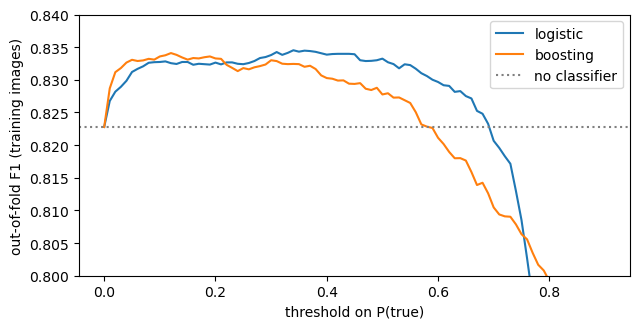

In [13]:
n_true_train = sum(count_from_coco(IMG_DIR, COCO)[2][name] for name in train_names)   # annotated cells in the training images

curves = {}
for name in ["logistic", "boosting"]:
    scores = oof_scores(CANDIDATES[name], objects, 5)         # out-of-fold P(true); border objects get 1
    curves[name] = [object_prf(objects, n_true_train, scores >= t)["obj_f1"] for t in THRESHOLDS]
    best = int(np.argmax(curves[name]))
    print(f"{name:9s}: best threshold {THRESHOLDS[best]:.2f}, out-of-fold F1 {curves[name][best]:.4f}")

plt.figure(figsize=(6.5, 3.4))
for name, f1 in curves.items():
    plt.plot(THRESHOLDS, f1, label=name)
plt.axhline(curves["logistic"][0], color="grey", linestyle=":", label="no classifier")
plt.ylim(0.80, 0.84)
plt.xlabel("threshold on P(true)")
plt.ylabel("out-of-fold F1 (training images)")
plt.legend()
plt.tight_layout()
plt.show()

The two models are equivalent (out-of-fold F1 0.8345 and 0.8341, against 0.823 without classifier): the logistic regression
is kept because it is simpler and its weights can be read. Objects with P(true) below 0.34 are dropped. The classifier trained on
all training objects is saved once (`classifier.joblib`) and used as it is on the validation and test images. Its weights
(on standardized features: the sign says in which direction the feature pushes towards "true"):

In [14]:
classifier = joblib.load(RUN / "object_classifier_ws20" / "classifier.joblib")
weights = pd.Series(classifier[-1].coef_[0], index=FEATURES)
print(weights.sort_values(key=abs, ascending=False).round(2).to_string())
print("threshold on P(true):", THRESHOLD)

rel_contrast    0.79
mean_prob       0.77
solidity        0.48
local_bg       -0.33
n_objects      -0.16
nn_dist        -0.15
eccentricity    0.14
contrast        0.07
intensity       0.07
area           -0.04
threshold on P(true): 0.34


The strongest signals are the confidence of the network (`mean_prob`), the contrast relative to the other cells of the same
image and a compact shape (`solidity`).

## 7. The adopted pipeline on the validation images

The three versions of the pipeline on the same 43 validation images, adding one step at a time. `delivered_labels` is the
function that runs the whole adopted pipeline on one image (the same function is used on the test images).

In [15]:
rows_network, rows_watershed, rows_adopted = [], [], []
labels_watershed, tables = [], []
for i in range(len(val_names)):
    true_labels = label_instances(true_masks[i])
    rows_network.append(counts_row(label_instances(postprocess(probs[i], 0.5)), true_masks[i]))
    after_watershed = predict_labels(probs[i], 0.5, min_distance=MIN_DISTANCE)
    rows_watershed.append(counts_row(after_watershed, true_masks[i]))
    final_labels, table = delivered_labels(probs[i], images[i], true_labels, i, classifier)
    rows_adopted.append(counts_row(final_labels, true_masks[i]))
    labels_watershed.append(after_watershed)
    tables.append(table)

versions = {"network only": np.array(rows_network),
            "+ watershed": np.array(rows_watershed),
            "+ watershed + classifier (adopted)": np.array(rows_adopted)}
summary = []
for name, counts in versions.items():
    metrics = metrics_from_counts(counts)
    summary.append({"pipeline": name, "Dice": metrics["dice"], "F1": metrics["obj_f1"],
                    "precision": metrics["obj_precision"], "recall": metrics["obj_recall"],
                    "merged": metrics["n_merged"], "count MAE": metrics["count_mae"], "count bias": metrics["count_bias"]})
print(pd.DataFrame(summary).round(3).to_string(index=False))

adopted = metrics_from_counts(versions["+ watershed + classifier (adopted)"])
assert round(adopted["obj_f1"], 4) == 0.8123 and round(adopted["dice"], 4) == 0.7629

for metric in ["obj_f1", "obj_precision", "obj_recall", "dice", "count_mae"]:
    low, high = bootstrap_diff(versions["+ watershed + classifier (adopted)"], versions["network only"], metric)
    print(f"adopted - network only, {metric:13s}: 95% CI [{low:+.3f}, {high:+.3f}]")

                          pipeline  Dice    F1  precision  recall  merged  count MAE  count bias
                      network only 0.763 0.782      0.734   0.837      12      4.535       2.395
                       + watershed 0.763 0.791      0.740   0.850       8      4.605       2.512
+ watershed + classifier (adopted) 0.763 0.812      0.781   0.847       8      4.233       1.442
adopted - network only, obj_f1       : 95% CI [+0.020, +0.044]
adopted - network only, obj_precision: 95% CI [+0.034, +0.062]
adopted - network only, obj_recall   : 95% CI [-0.002, +0.025]
adopted - network only, dice         : 95% CI [-0.005, +0.004]
adopted - network only, count_mae    : 95% CI [-0.744, +0.163]


- The **watershed** splits merged cells: fewer merges and a higher recall.
- The **classifier** removes objects that are not annotated cells: a clearly higher precision, for a small loss of recall.
- Together the F1 goes from 0.782 to 0.812, demonstrably (the interval is above 0); the pixel Dice does not change.

## 8. What the classifier drops, and what it keeps

Crops of 80 × 80 px around some validation objects: the predicted object in magenta, the annotated cells in yellow.

dropped by the classifier: 46 | kept but not matching an annotated cell: 146


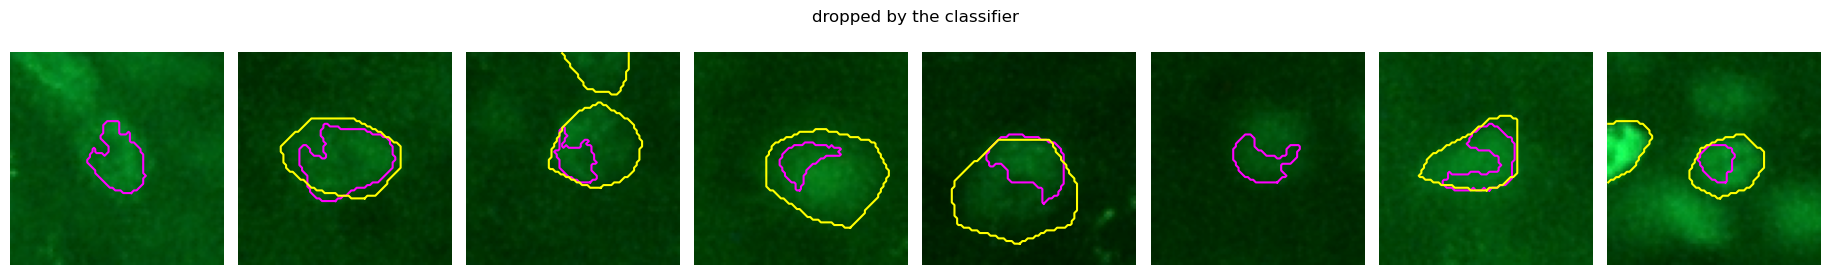

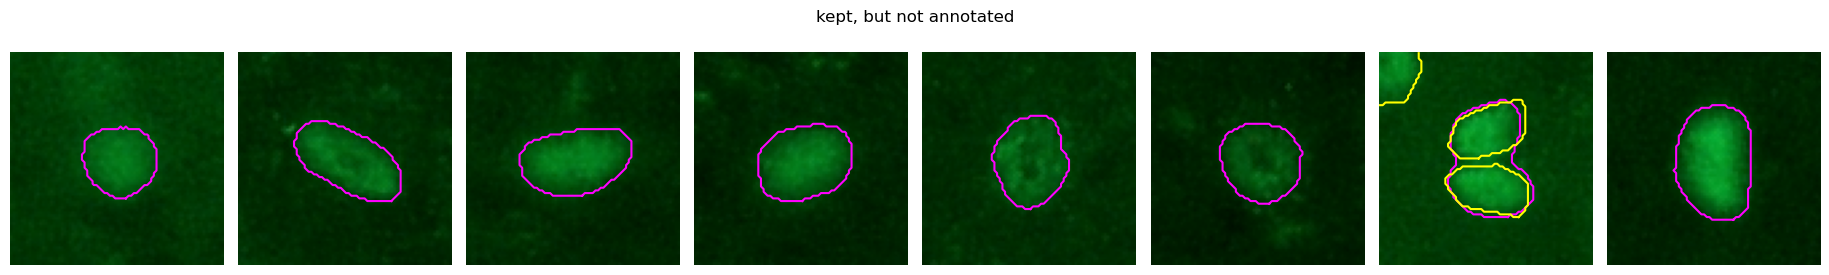

In [16]:
def show_objects(selected, title):
    '''Crops around some objects: predicted object in magenta, annotated cells in yellow.'''
    fig, axes = plt.subplots(1, len(selected), figsize=(2.3 * len(selected), 2.8))
    for ax, (i, obj) in zip(axes, selected):
        r, c = measure.regionprops((labels_watershed[i] == obj).astype(int))[0].centroid
        r0 = int(min(max(r - 40, 0), 1200 - 80))
        c0 = int(min(max(c - 40, 0), 1600 - 80))
        ax.imshow(np.clip(images[i][r0:r0 + 80, c0:c0 + 80] / 150, 0, 1))
        outline(ax, labels_watershed[i][r0:r0 + 80, c0:c0 + 80] == obj, "magenta")
        outline(ax, true_masks[i][r0:r0 + 80, c0:c0 + 80], "yellow")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

dropped, kept_false = [], []
for i, table in enumerate(tables):
    for _, row in table.iterrows():
        if not row.keep:
            dropped.append((i, int(row.obj)))
        elif row.label == 0 and not row.border:
            kept_false.append((i, int(row.obj)))
print(f"dropped by the classifier: {len(dropped)} | kept but not matching an annotated cell: {len(kept_false)}")

rng = np.random.default_rng(0)
show_objects([dropped[k] for k in rng.choice(len(dropped), 8, replace=False)], "dropped by the classifier")
show_objects([kept_false[k] for k in rng.choice(len(kept_false), 8, replace=False)], "kept, but not annotated")

- **Dropped:** mostly small or irregular objects and pieces of cells (fragments that would never match a cell with IoU > 0.5).
- **Kept but not annotated:** mostly round, well-formed objects that look like cells, often somewhat fainter: plausible
  cells that the annotators left out. No feature separates them from the annotated cells: this is the ambiguity of the
  labels seen in section 4, and it is the main limit of the pipeline.

## 9. Tried and not adopted

Other post-processing ideas that were tested and not adopted (measured before the watershed was added, against the pipeline
of that moment; same decision rule: adopted only if the F1 improves demonstrably). Details in `experiments/`.

| idea | result | decision |
|---|---|---|
| other probability thresholds (0.3–0.7) | no difference (section 2) | 0.5 kept |
| minimum area 400 px instead of 120 | validation F1 +0.004, 95% CI [−0.006, +0.013]; precision up, recall down | not adopted: only trades recall for precision |
| watershed with seeds 12 px apart | validation F1 +0.010, CI [−0.004, +0.028]; cuts 5 single cells in two on the training images | not adopted: 20 px chosen instead (section 5) |
| test-time augmentation (average of the 8 flips/rotations) | training images: F1 +0.0003, CI [−0.006, +0.007] | not adopted: the network is already confident |
| morphological closing (to repair fragmented cells) | on the training images it would join 27 pairs of different cells to repair at most 11 | not adopted |
| more features from the annotation protocol (roundness, dark nucleoli, edge sharpness, size, texture) | cross-validation F1 −0.0007 | not adopted: redundant with the existing features |
| adding candidate cells found by other methods (robust threshold, Cellpose) with a second classifier | cross-validation F1 +0.0001 and +0.003 | not adopted: the added candidates are mostly false |

## 10. Summary

```
probability map (network v2, epoch 79)
  → threshold 0.5 → fill holes → remove objects < 120 px
  → watershed, seeds at least 20 px apart
  → object classifier: logistic regression on 10 features, keep if P(true) ≥ 0.34 (border objects always kept)
```

On the validation images: F1 0.812 (precision 0.781, recall 0.847), Dice 0.763, 8 merged objects, ~4 cells of counting error
per image. Notebook 04 applies exactly this pipeline to the test images.